In [2]:
import pandas as pd
games = pd.read_csv("/content/games.csv", sep=';')
games.head()
games.columns.tolist()

import json

with open("/content/champion_names&roles.json", "r", encoding="utf-8") as f:
    champ_data = json.load(f)

role_map = {}

for champ_name, info in champ_data["data"].items():
    champ_id = int(info["key"])
    primary_role = info["tags"][0]
    role_map[champ_id] = primary_role

list(role_map.items())[:10]

t1_cols = [f"t1_champ{i}id" for i in range(1, 6)]
t2_cols = [f"t2_champ{i}id" for i in range(1, 6)]

def get_role_counts(champion_ids):
    roles = [role_map.get(champ_id, "Unknown") for champ_id in champion_ids]

    counts = {
        "Marksman": roles.count("Marksman"),
        "Tank": roles.count("Tank"),
        "Mage": roles.count("Mage"),
        "Assassin": roles.count("Assassin"),
        "Support": roles.count("Support"),
        "Fighter": roles.count("Fighter"),
        "diversity": len(set(roles))
    }

    return counts

rows = []

for _, row in games.iterrows():
    # Team 1
    t1_ids = row[t1_cols].tolist()
    t1_features = get_role_counts(t1_ids)
    t1_features["win"] = 1 if row["winner"] == 1 else 0
    rows.append(t1_features)

    # Team 2
    t2_ids = row[t2_cols].tolist()
    t2_features = get_role_counts(t2_ids)
    t2_features["win"] = 1 if row["winner"] == 2 else 0
    rows.append(t2_features)

team_df = pd.DataFrame(rows)
team_df.head()

team_df.to_csv("/content/team_role_dataset.csv", index=False)

diversity_winrate = team_df.groupby("diversity")["win"].mean()
diversity_winrate

import matplotlib.pyplot as plt

ax = diversity_winrate.plot(marker="o")
plt.title("Trend of Win Rate by Role Diversity")
plt.xlabel("Unique Role Count")
plt.ylabel("Win Rate")

for x, y in zip(diversity_winrate.index, diversity_winrate.values):
    plt.text(x, y + 0.005, f"{y:.2f}", ha="center")

plt.show()

team_df["diversity"].value_counts().sort_index().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Distribution of Role Diversity")
plt.ylabel("")
plt.show()
"""
diversity_winrate.plot(kind="bar")
plt.title("Win Rate by Role Diversity")
plt.xlabel("Number of Unique Roles")
plt.ylabel("Win Rate")
plt.show()

support_winrate = team_df.groupby(team_df["Support"] > 0)["win"].mean()
support_winrate

support_winrate.plot(kind="bar")
plt.title("Win Rate: Support vs No Support")
plt.xlabel("Has Support")
plt.ylabel("Win Rate")
plt.show()

winning_avg_roles = team_df[team_df["win"] == 1][
    ["Marksman", "Tank", "Mage", "Assassin", "Support", "Fighter"]
].mean()

winning_avg_roles

winning_avg_roles.plot(kind="bar")
plt.title("Average Role Counts in Winning Teams")
plt.xlabel("Role")
plt.ylabel("Average Count")
plt.show()

double_marksman = team_df.groupby(team_df["Marksman"] >= 2)["win"].mean()
double_marksman

ax = double_marksman.plot(kind="bar")
plt.title("Win Rate: Double Marksman vs Others")
plt.xlabel("Has Double Marksman")
plt.ylabel("Win Rate")

for i, v in enumerate(double_marksman):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()

assassin_groups = team_df.copy()

assassin_groups["Assassin Group"] = assassin_groups["Assassin"].apply(
    lambda x: "0" if x == 0 else ("1" if x == 1 else "2+")
)

assassin_winrate = assassin_groups.groupby("Assassin Group")["win"].mean()
assassin_winrate

ax = assassin_winrate.plot(kind="bar")
plt.title("Win Rate by Number of Assassins")
plt.xlabel("Assassin Count")
plt.ylabel("Win Rate")

for i, v in enumerate(assassin_winrate):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()


synergy_df = team_df[team_df["Marksman"] >= 1].copy()

synergy_df["ADC Support Setup"] = synergy_df["Support"].apply(
    lambda x: "Marksman + Support" if x >= 1 else "Marksman without Support"
)

adc_support_winrate = synergy_df.groupby("ADC Support Setup")["win"].mean()
adc_support_winrate

ax = adc_support_winrate.plot(kind="bar")
plt.title("Win Rate: Marksman With vs Without Support")
plt.xlabel("Composition Type")
plt.ylabel("Win Rate")

for i, v in enumerate(adc_support_winrate):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()


tank_groups = team_df.copy()

tank_groups["Tank Group"] = tank_groups["Tank"].apply(
    lambda x: "0" if x == 0 else ("1" if x == 1 else "2+")
)

tank_winrate = tank_groups.groupby("Tank Group")["win"].mean()
tank_winrate

ax = tank_winrate.plot(kind="bar")
plt.title("Win Rate by Number of Tanks")
plt.xlabel("Tank Count")
plt.ylabel("Win Rate")

for i, v in enumerate(tank_winrate):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()




winning_comps = (
    team_df[team_df["win"] == 1]
    .groupby(["Marksman", "Tank", "Mage", "Assassin", "Support", "Fighter"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

winning_comps

formatted_labels = [
    f"Marksman:{idx[0]} | Tank:{idx[1]} | Mage:{idx[2]} | "
    f"Assassin:{idx[3]} | Support:{idx[4]} | Fighter:{idx[5]}"
    for idx in winning_comps.index
]

ax = winning_comps.plot(kind="bar", figsize=(12, 6))
plt.title("Top 10 Most Common Winning Compositions")
plt.xlabel("Role Composition")
plt.ylabel("Frequency")

ax.set_xticklabels(formatted_labels, rotation=45, ha="right")

for i, v in enumerate(winning_comps):
    ax.text(i, v + 50, str(v), ha="center")

plt.tight_layout()
plt.show()

diversity_distribution = team_df["diversity"].value_counts().sort_index()
diversity_distribution

ax = diversity_distribution.plot(kind="bar")
plt.title("Distribution of Role Diversity")
plt.xlabel("Unique Role Count")
plt.ylabel("Number of Teams")

for i, v in enumerate(diversity_distribution):
    ax.text(i, v + 50, str(v), ha="center")

plt.show()

low_div_comps = (
    team_df[team_df["diversity"] <= 2]
    .groupby(["Marksman", "Tank", "Mage", "Assassin", "Support", "Fighter"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

low_div_comps

low_div_labels = [
    f"Marksman:{idx[0]} | Tank:{idx[1]} | Mage:{idx[2]} | "
    f"Assassin:{idx[3]} | Support:{idx[4]} | Fighter:{idx[5]}"
    for idx in low_div_comps.index
]

ax = low_div_comps.plot(kind="bar", figsize=(12, 6))
plt.title("Top Low-Diversity Team Compositions")
plt.xlabel("Role Composition")
plt.ylabel("Frequency")

ax.set_xticklabels(low_div_labels, rotation=45, ha="right")

for i, v in enumerate(low_div_comps):
    ax.text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

high_div_wins = (
    team_df[(team_df["diversity"] >= 4) & (team_df["win"] == 1)]
    .groupby(["Marksman", "Tank", "Mage", "Assassin", "Support", "Fighter"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

high_div_wins

high_div_labels = [
    f"Marksman:{idx[0]} | Tank:{idx[1]} | Mage:{idx[2]} | "
    f"Assassin:{idx[3]} | Support:{idx[4]} | Fighter:{idx[5]}"
    for idx in high_div_wins.index
]

ax = high_div_wins.plot(kind="bar", figsize=(12, 6))
plt.title("Top Winning High-Diversity Compositions")
plt.xlabel("Role Composition")
plt.ylabel("Frequency")

ax.set_xticklabels(high_div_labels, rotation=45, ha="right")

for i, v in enumerate(high_div_wins):
    ax.text(i, v + 50, str(v), ha="center")

plt.tight_layout()
plt.show()
"""

X = team_df.drop("win", axis=1)
y = team_df["win"]

FileNotFoundError: [Errno 2] No such file or directory: '/content/games.csv'

In [ ]:
import pandas as pd
team_df = pd.read_csv("/content/team_role_dataset.csv", sep=";")
team_df.head()

,Marksman,Tank,Mage,Assassin,Support,Fighter,diversity,win
0,1,0,2,1,1,0,4,1
1,2,0,0,1,1,1,4,0
2,1,0,0,2,0,2,3,1
3,0,1,1,0,0,3,3,0
4,1,0,0,1,1,2,4,1


### Hypotheses
- **H0:** Role diversity and winning are independent.
- **H1:** There is a statistically significant relationship between role diversity and winning.

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(team_df["diversity"], team_df["win"])

print("Contingency Table:")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Contingency Table:
win            0      1
diversity              
1              5      2
2            248    197
3           8549   7879
4          30332  30348
5          12356  13064

Chi-square statistic: 54.179451390686104
p-value: 4.826464458492728e-11
Degrees of freedom: 4


### Interpretation
The chi-square test returned a p-value of 4.83e-11, which is far below the significance threshold of 0.05.

Therefore, the null hypothesis is rejected.

This confirms that team role diversity and match outcomes are statistically dependent, supporting the earlier EDA findings that higher diversity is associated with improved win rates.

In [9]:
# =========================
# 1. DATA LOAD
# =========================
import pandas as pd

team_df = pd.read_csv("/content/team_role_dataset.csv", sep=';')

# =========================
# 2. FEATURE ENGINEERING
# =========================
team_df["has_marksman"] = (team_df["Marksman"] > 0).astype(int)
team_df["has_support"] = (team_df["Support"] > 0).astype(int)
team_df["has_tank"] = (team_df["Tank"] > 0).astype(int)

team_df["is_balanced"] = (team_df["diversity"] >= 4).astype(int)
team_df["double_fighter"] = (team_df["Fighter"] >= 2).astype(int)

team_df["marksman_support_combo"] = (
    (team_df["Marksman"] > 0) & (team_df["Support"] > 0)
).astype(int)

team_df["high_diversity"] = (team_df["diversity"] >= 4).astype(int)

# =========================
# 3. FEATURE / TARGET
# =========================
X = team_df.drop("win", axis=1)
y = team_df["win"]

# =========================
# 4. TRAIN / TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 5. LOGISTIC REGRESSION
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))


# =========================
# 6. RANDOM FOREST
# =========================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))


# =========================
# 7. FEATURE IMPORTANCE
# =========================
import pandas as pd

importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("\n=== Feature Importance ===")
print(feat_imp)

=== Logistic Regression ===
Accuracy: 0.5112157700524373
Precision: 0.513455629015737
Recall: 0.5324449594438007
F1-score: 0.5227779094572174

=== Random Forest ===
Accuracy: 0.5079141580889494
Precision: 0.5086551264980027
Recall: 0.627076091154886
F1-score: 0.5616918219954158

=== Feature Importance ===
Assassin                  0.147496
Mage                      0.142155
Fighter                   0.114808
Marksman                  0.113746
Tank                      0.102329
Support                   0.098746
diversity                 0.063325
marksman_support_combo    0.043120
has_support               0.042422
has_tank                  0.039271
has_marksman              0.027819
double_fighter            0.027482
high_diversity            0.019893
is_balanced               0.017387
dtype: float64


=== Logistic Regression Metrics ===
              precision    recall  f1-score   support

           0       0.52      0.48      0.50     10298
           1       0.52      0.55      0.53     10298

    accuracy                           0.52     20596
   macro avg       0.52      0.52      0.52     20596
weighted avg       0.52      0.52      0.52     20596


=== Logistic Regression Coefficients (Kazanmaya Etki Derecesi) ===
                   Feature  Coefficient
6                diversity     0.078731
11  marksman_support_combo     0.060188
10          double_fighter     0.059946
8              has_support     0.040628
1                     Tank     0.009894
12          high_diversity     0.006225
7             has_marksman    -0.021126
0                 Marksman    -0.033937
2                     Mage    -0.063987
5                  Fighter    -0.069357
9                 has_tank    -0.075482
3                 Assassin    -0.089854
4                  Support    -0.100682

=== Rand

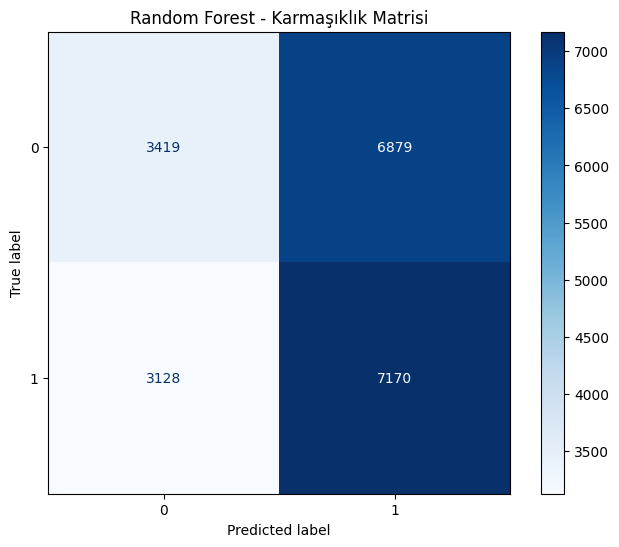

=== Delta Model (Match-wise) Metrics ===
              precision    recall  f1-score   support

           0       0.51      0.40      0.45      5083
           1       0.52      0.63      0.57      5215

    accuracy                           0.52     10298
   macro avg       0.51      0.51      0.51     10298
weighted avg       0.51      0.52      0.51     10298


=== Delta Coefficients (Kazanma Üstünlüğü) ===
           Feature  Coefficient
6  delta_diversity     0.075454
4    delta_Support     0.039048
5    delta_Fighter     0.013258
1       delta_Tank     0.011085
0   delta_Marksman     0.010827
2       delta_Mage    -0.023809
3   delta_Assassin    -0.050409


/tmp/ipykernel_4996/477948411.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="delta_diversity", y="win", data=delta_df, palette="viridis")


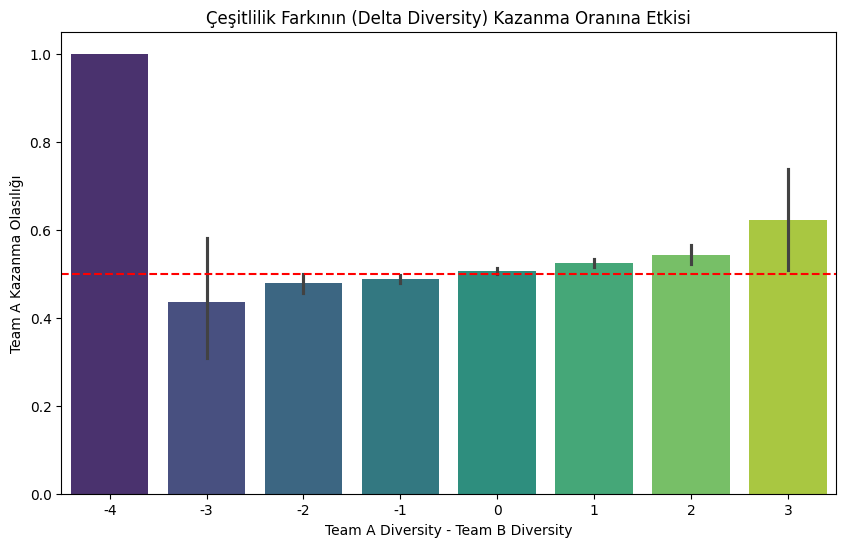


=== 5-Fold Cross-Validation Scores ===
Scores: [0.51806176 0.51932414 0.51854729 0.51854729 0.50922509]
Mean CV Accuracy: 0.5167


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)


team_df = pd.read_csv("/content/team_role_dataset.csv", sep=';')


team_df["has_marksman"] = (team_df["Marksman"] > 0).astype(int)
team_df["has_support"] = (team_df["Support"] > 0).astype(int)
team_df["has_tank"] = (team_df["Tank"] > 0).astype(int)
team_df["double_fighter"] = (team_df["Fighter"] >= 2).astype(int)


team_df["marksman_support_combo"] = (
    (team_df["Marksman"] > 0) & (team_df["Support"] > 0)
).astype(int)


team_df["high_diversity"] = (team_df["diversity"] >= 4).astype(int)


X = team_df.drop("win", axis=1)
y = team_df["win"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("=== Logistic Regression Metrics ===")
y_pred_log = log_model.predict(X_test)
print(classification_report(y_test, y_pred_log))


coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": log_model.coef_[0]})
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)
print("\n=== Logistic Regression Coefficients (Kazanmaya Etki Derecesi) ===")
print(coef_df)


rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"\n=== Random Forest Check ===")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
if train_acc - test_acc > 0.1:
    print("UYARI: Modelde Overfitting olabilir!")


importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print("\n=== Random Forest Feature Importance ===")
print(feat_imp.head(5))


fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Random Forest - Karmaşıklık Matrisi")
plt.show()



team_A = team_df.iloc[::2].reset_index(drop=True)
team_B = team_df.iloc[1::2].reset_index(drop=True)


delta_df = pd.DataFrame()
roles = ["Marksman", "Tank", "Mage", "Assassin", "Support", "Fighter", "diversity"]

for role in roles:
    delta_df[f"delta_{role}"] = team_A[role] - team_B[role]


y_delta = team_A["win"].values


X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    delta_df, y_delta, test_size=0.2, random_state=42, stratify=y_delta
)


log_delta = LogisticRegression()
log_delta.fit(X_train_d, y_train_d)

print("=== Delta Model (Match-wise) Metrics ===")
y_pred_delta = log_delta.predict(X_test_d)
print(classification_report(y_test_d, y_pred_delta)) #


delta_coef = pd.DataFrame({"Feature": delta_df.columns, "Coefficient": log_delta.coef_[0]})
print("\n=== Delta Coefficients (Kazanma Üstünlüğü) ===")
print(delta_coef.sort_values(by="Coefficient", ascending=False))


delta_df["win"] = y_delta
plt.figure(figsize=(10, 6))
sns.barplot(x="delta_diversity", y="win", data=delta_df, palette="viridis")
plt.title("Çeşitlilik Farkının (Delta Diversity) Kazanma Oranına Etkisi")
plt.xlabel("Team A Diversity - Team B Diversity")
plt.ylabel("Team A Kazanma Olasılığı")
plt.axhline(0.5, ls='--', color='red')
plt.show()


from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(log_delta, delta_df.drop("win", axis=1), y_delta, cv=5)

print("\n=== 5-Fold Cross-Validation Scores ===")
print(f"Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")